In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from mcbuild_generator.constants.paths import *

sns.set_theme()

### Global

In [2]:
filenames = os.listdir(os.path.join("..", BUILDS_DIR))

print(f"Total Files: {len(filenames)}")

extensions = [f.split(".")[-1] for f in filenames]

counts = Counter(extensions)
print(counts)

Total Files: 28236
Counter({'schem': 28235, 'gitkeep': 1})


### Schem Files

In [3]:
metadata_df = pd.read_csv(os.path.join("..", BUILDS_METADATA_CSV))

#### Outliers

In [39]:
COLUMN = "palettemax"

In [40]:
Q1 = metadata_df[COLUMN].quantile(0.25)
Q3 = metadata_df[COLUMN].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

metadata_df_filtered = metadata_df[
    (metadata_df[COLUMN] >= lower) & (metadata_df[COLUMN] <= upper)
]

In [45]:
median = metadata_df[COLUMN].median()
MAD = (metadata_df[COLUMN] - median).abs().median()

# approximate standard deviation scaling
threshold = 3 * 1.4826 * MAD
metadata_df_filtered = metadata_df[(metadata_df[COLUMN] - median).abs() <= threshold]

count : 28235


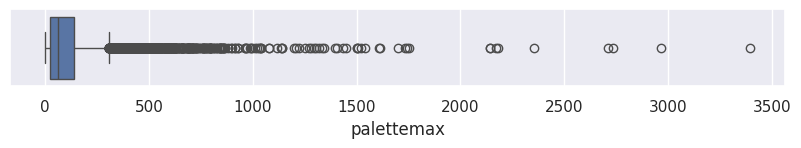

In [46]:
print(f"count : {len(metadata_df)}")
plt.figure(figsize=(10, 1))
sns.boxplot(metadata_df, x=COLUMN)
plt.show()

count : 26205


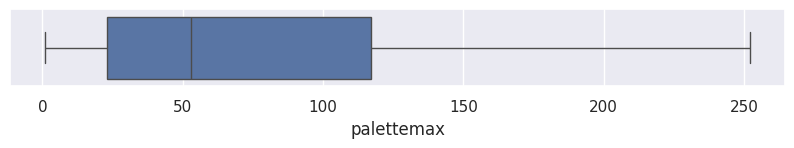

In [44]:
print(f"count : {len(metadata_df_filtered)}")
plt.figure(figsize=(10, 1))
sns.boxplot(metadata_df_filtered, x=COLUMN)
plt.show()

#### Palettemaxs

In [84]:
palettemaxs_arr = np.array(palettemaxs)

In [87]:
# remove outliers
palettemaxs_arr = palettemaxs_arr[palettemaxs_arr < 2000]
print(palettemaxs_arr.max())
print(f"removed count : {len(palettemaxs) - len(palettemaxs_arr)}")

1751
removed count : 9


<Axes: >

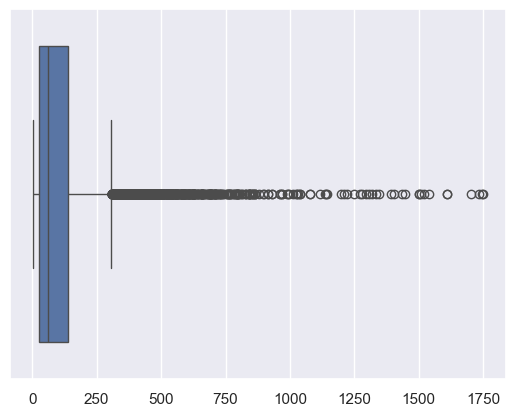

In [88]:
sns.boxplot(x=palettemaxs_arr)

#### BlockEntities

In [93]:
blockentities_count_arr = np.array(blockentities_count)

In [94]:
# remove outliers
blockentities_count_arr = blockentities_count_arr[blockentities_count_arr < 10e8]
print(blockentities_count_arr.max())
print(f"removed count : {len(blockentities_count) - len(blockentities_count_arr)}")

0
removed count : 0


<Axes: >

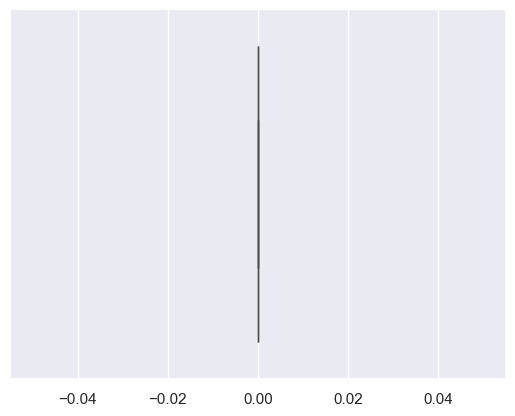

In [95]:
sns.boxplot(x=blockentities_count_arr)